#  0. 미션 개요

쇼핑몰 리뷰 데이터를 대상으로 감성 분석을 해 보는 미션

##  사용 데이터셋
- 쇼핑몰 패션 리뷰 (JSON 형식)
- RawText: 리뷰 텍스트
- GeneralPolarity: 감성 레이블 (-1: 부정, 0: 중립, 1: 긍정)

##  사용 모델
- beomi/KcELECTRA-base: 한국어 대규모 코퍼스로 사전학습된 ELECTRA 모델

##  학습 방법 요약
| 방법 | 설명 | 업데이트 파라미터 |
|------|------|------------------|
| Full Fine-Tuning | 모델 전체 파라미터 업데이트 | 100% |
| Partial Fine-Tuning | 마지막 레이어 + 분류기만 학습 | ~1~5% |
| LoRA | 저차원 행렬로 가중치 변화량 근사 | ~0.8% |
| AdaLoRA | 랭크를 적응적으로 조절하는 LoRA | ~0.5~1% |
| EIA | IA3의 확장 - 더 넓은 레이어에 스케일링 벡터 적용 | <1% |
| Prompt Tuning | 입력 앞에 학습 가능한 소프트 프롬프트 추가 | <0.1% |

# 1. 환경 설정

In [ ]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# 필요한 라이브러리 설치
# torchao 버전 충돌 방지: peft가 요구하는 최소 버전(0.16.0)으로 업그레이드
!pip install -q datasets accelerate evaluate peft scikit-learn
!pip install -q --upgrade torchao


In [ ]:
# 라이브러리 불러오기
import os
import json
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import subprocess
import matplotlib.font_manager as fm

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split as sklearn_split

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

import evaluate
import torch
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from peft import get_peft_model, LoraConfig, TaskType, AdaLoraConfig, IA3Config, get_peft_model, PromptTuningConfig, PromptTuningInit
import math

# 2. 데이터 로드 및 전처리

In [ ]:
# 1. 데이터 경로 설정 
data_dir = "/content/drive/MyDrive/data/review-sentiment-analysis/쇼핑몰/01. 패션"

# 2. JSON 파일 경로 수집 
json_paths = []
for root, _, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".json"):
            json_paths.append(os.path.join(root, file))

print(f" 총 JSON 파일 수: {len(json_paths)}개")

# 3. JSON 파싱 및 데이터 수집
data = []

for path in json_paths:
    with open(path, 'r', encoding='utf-8') as f:
        try:
            items = json.load(f)  # JSON 파일 로드
            for item in items:
                polarity = item.get("GeneralPolarity", None)  # 감성 레이블 추출
                text = item.get("RawText", None)              # 리뷰 텍스트 추출

                # 두 필드가 모두 있고 유효한 값인 경우만 추가
                if polarity is not None and text:
                    polarity = int(polarity)
                    if polarity in [-1, 0, 1]:  # 유효 범위 체크
                        data.append({
                            "text": text,
                            "label": polarity + 1   # -1 → 0(부정), 0 → 1(중립), 1 → 2(긍정) 으로 변환
                        })
        except Exception:
            continue  

# 4. DataFrame 
df = pd.DataFrame(data)
df = df.dropna()           # 결측값 제거
df = df.drop_duplicates()  # 중복 제거

print(f"\n 총 리뷰 수: {len(df)}개")
print("\n 레이블 분포:")
label_counts = df["label"].value_counts().sort_index()
label_names = {0: "부정(Negative)", 1: "중립(Neutral)", 2: "긍정(Positive)"}
for label, count in label_counts.items():
    print(f"  {label_names[label]}: {count}개 ({count/len(df)*100:.1f}%)")

 총 JSON 파일 수: 450개

 총 리뷰 수: 44398개

 레이블 분포:
  부정(Negative): 9264개 (20.9%)
  중립(Neutral): 8683개 (19.6%)
  긍정(Positive): 26451개 (59.6%)


- 원본: -1(부정), 0(중립), 1(긍정)
- 변환 후: 0(부정), 1(중립), 2(긍정)
- PyTorch 및 Hugging Face 모델은 레이블이 0부터 시작하는 정수여야해서 변환함.

## - 데이터 EDA

나눔 폰트를 찾지 못했습니다. 런타임 재시작 후 다시 실행하세요.


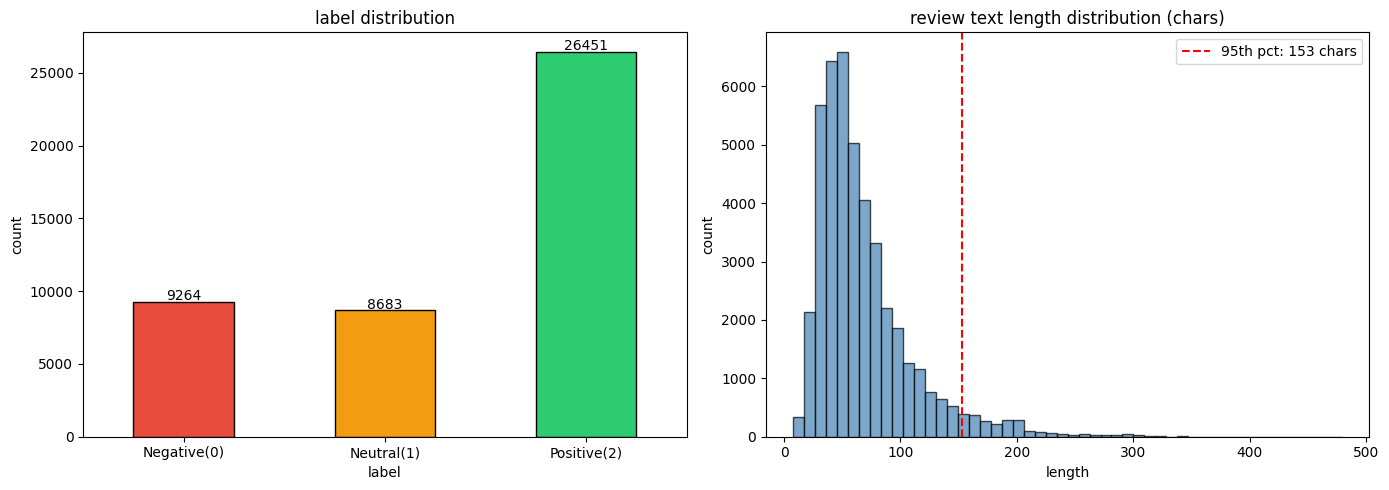

text length stats:
  mean   : 68.3 chars
  median : 57.0 chars
  max    : 479 chars
  95th   : 153 chars


In [ ]:
# Colab 환경에서 한글 폰트 설치
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)

# 한글 폰트 설정
fm._load_fontmanager(try_read_cache=False)
nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
if nanum_fonts:
    matplotlib.rcParams['font.family'] = nanum_fonts[0]
    print(f'폰트 설정 완료: {nanum_fonts[0]}')
else:
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
    print('나눔 폰트를 찾지 못했습니다. 런타임 재시작 후 다시 실행하세요.')

matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 레이블 분포 시각화
label_counts = df['label'].value_counts().sort_index()
label_counts.plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='black'
)
axes[0].set_title('label distribution')
axes[0].set_xlabel('label')
axes[0].set_ylabel('count')
axes[0].set_xticklabels(['Negative(0)', 'Neutral(1)', 'Positive(2)'], rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 100, str(v), ha='center')

# 텍스트 길이 분포 시각화
text_lengths = df['text'].str.len()
axes[1].hist(text_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('review text length distribution (chars)')
axes[1].set_xlabel('length')
axes[1].set_ylabel('count')
axes[1].axvline(text_lengths.quantile(0.95), color='red', linestyle='--',
                label=f'95th pct: {text_lengths.quantile(0.95):.0f} chars')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'text length stats:')
print(f'  mean   : {text_lengths.mean():.1f} chars')
print(f'  median : {text_lengths.median():.1f} chars')
print(f'  max    : {text_lengths.max()} chars')
print(f'  95th   : {text_lengths.quantile(0.95):.0f} chars')


나눔 폰트가 적용이 안되어서, 시각화 자료에 영어만 포함하였음.

레이블 분포가 긍정(2)에 많은 데이터가 존재하여 클래스 불균형 상태임. -> 해결 필요

## - Train / Test 분할

- 전체 데이터를 80:20 비율로 분할
- `seed=42`로 재현성 보장
- Hugging Face `Dataset` 객체를 사용하면 이후 `map()`, `set_format()` 등을 효율적으로 활용 가능

In [ ]:
# ─── pandas 단계에서 층화 샘플링으로 분할 ────────────────────────
# datasets의 train_test_split()은 stratify_by_column에 ClassLabel 타입만 허용하므로, sklearn으로 먼저 분할 후 Dataset 변환
train_df, test_df = sklearn_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # 레이블 비율 유지 (층화 샘플링)
)

# 인덱스 초기화 (pandas → HF Dataset 변환 시 필요)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Hugging Face DatasetDict로 변환
# Arrow 포맷 기반으로 대용량 데이터를 메모리 효율적으로 처리
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'test' : Dataset.from_pandas(test_df),
})

print(f"학습 데이터 크기: {len(dataset['train'])}개")
print(f"테스트 데이터 크기: {len(dataset['test'])}개")

# 층화 샘플링 확인
print("\n레이블 분포 확인 (비율):")
import pandas as pd
for split in ['train', 'test']:
    counts = pd.Series(dataset[split]['label']).value_counts(normalize=True).sort_index()
    print(f"  {split}: 부정={counts.get(0,0):.1%}  중립={counts.get(1,0):.1%}  긍정={counts.get(2,0):.1%}")


학습 데이터 크기: 35518개
테스트 데이터 크기: 8880개

레이블 분포 확인 (비율):
  train: 부정=20.9%  중립=19.6%  긍정=59.6%
  test: 부정=20.9%  중립=19.6%  긍정=59.6%


# 3. 토크나이징

KcELECTRA-base 선택 이유
- 한국어 특화 ELECTRA 모델 (Korean Comments ELECTRA)
- 쇼핑몰, SNS 등의 구어체 한국어에 강점 (리뷰 데이터와 적합)
- BERT보다 더 효율적인 사전학습 방식 (판별자 기반)

In [ ]:
# 모델 이름 설정
MODEL_NAME = "beomi/KcELECTRA-base"
NUM_LABELS = 3  # 부정/중립/긍정
MAX_LENGTH = 128  # 토큰 최대 길이

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(example):
    tokenized = tokenizer(
        example["text"],
        truncation=True,          # 최대 길이 초과 시 잘라냄
        padding="max_length",     # max_length까지 패딩 토큰 추가
        max_length=MAX_LENGTH     # 최대 토큰 수
    )
    tokenized["text"] = example["text"]  # 원본 텍스트 보존
    return tokenized


# 데이터셋에 전처리 적용 (batched=True: 배치 단위로 처리하여 속도 향상)
tokenized_dataset = dataset.map(preprocess, batched=True)

# 컬럼명 변경: Trainer가 레이블 컬럼을 'labels'로 인식
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# PyTorch 텐서 형식으로 포맷 설정
tokenized_dataset.set_format(
    type="torch",
    columns=["text", "input_ids", "attention_mask", "labels"]
)

print("토크나이징 완료!")
print(f"학습 데이터: {len(tokenized_dataset['train'])}개")
print(f"테스트 데이터: {len(tokenized_dataset['test'])}개")

# 샘플 확인
sample = tokenized_dataset['train'][0]
print(f"\n샘플 텍스트: {sample['text'][:50]}...")
print(f"input_ids 길이: {len(sample['input_ids'])}")
print(f"레이블: {sample['labels']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Map:   0%|          | 0/35518 [00:00<?, ? examples/s]

Map:   0%|          | 0/8880 [00:00<?, ? examples/s]

토크나이징 완료!
학습 데이터: 35518개
테스트 데이터: 8880개

샘플 텍스트: 예쁜 핑크베이지긴 한데 핏이 쪼금 애매하네요.. 그래도 가격생각하면 득템입니덩...
input_ids 길이: 128
레이블: 1


# 4. 공통 유틸리티 함수 정의

In [ ]:
# 비교 결과를 저장할 딕셔너리
comparison_results = {}


# Trainer의 평가 단계에서 호출되는 지표 계산 함수
def compute_metrics_fn(eval_pred):
    
    accuracy = evaluate.load("accuracy")
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1)  # 가장 높은 logit → 예측 클래스
    return accuracy.compute(predictions=preds, references=labels)


# 클래스 불균형 보정을 위한 가중치 계산
def compute_class_weights():

    from sklearn.utils.class_weight import compute_class_weight
    labels = np.array(tokenized_dataset['train']['labels'])
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels),
        y=labels
    )
    print(f'클래스 가중치: 부정={weights[0]:.3f}, 중립={weights[1]:.3f}, 긍정={weights[2]:.3f}')
    return torch.tensor(weights, dtype=torch.float)

# 클래스 불균형 보정용 커스텀 Trainer
class WeightedLossTrainer(Trainer):
   
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.model.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        # weighted cross entropy: 소수 클래스에 더 높은 패널티
        loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


# 클래스 가중치 사전 계산 (모든 학습에서 공통 사용)
class_weights = compute_class_weights()

# WeightedLossTrainer 객체 생성, 클래스 불균형을 반영한 weighted cross entropy loss 적용
def create_trainer(model, training_args):

    return WeightedLossTrainer(
        class_weights=class_weights,
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset['train'],
        eval_dataset=tokenized_dataset['test'],
        compute_metrics=compute_metrics_fn,
    )

# 테스트 데이터에 대한 예측 수행 후 예측 레이블과 실제 레이블 반환
def get_predictions(trainer):
   
    predictions = trainer.predict(tokenized_dataset["test"])
    pred_labels = torch.argmax(torch.tensor(predictions.predictions), dim=1)
    true_labels = predictions.label_ids
    return pred_labels.numpy(), true_labels

# 모델 성능 종합 평가 및 결과 저장
def evaluate_model(method_name, pred_labels, true_labels, train_time, model_size_mb):
    
    acc = accuracy_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels, average='macro')          # 클래스 불균형 고려
    precision = precision_score(true_labels, pred_labels, average='macro')
    recall = recall_score(true_labels, pred_labels, average='macro')

    print(f"\n{'='*50}")
    print(f" [{method_name}] 성능 평가 결과")
    print(f"{'='*50}")
    print(f"   Accuracy  : {acc*100:.2f}%")
    print(f"   F1-Score  : {f1*100:.2f}% (macro)")
    print(f"   Precision : {precision*100:.2f}% (macro)")
    print(f"   Recall    : {recall*100:.2f}% (macro)")
    print(f"   학습 시간 : {train_time:.1f}초 ({train_time/60:.1f}분)")
    print(f"   모델 크기 : {model_size_mb:.1f} MB")

    # Confusion Matrix 출력
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Negative", "Neutral", "Positive"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"Confusion Matrix - {method_name}")
    plt.tight_layout()
    plt.show()

    # 상세 분류 리포트
    print("\n 상세 분류 리포트:")
    print(classification_report(true_labels, pred_labels,
                                target_names=["Negative", "Neutral", "Positive"]))

    # 결과 저장 (최종 비교에 사용)
    comparison_results[method_name] = {
        'accuracy': acc * 100,
        'f1_macro': f1 * 100,
        'precision': precision * 100,
        'recall': recall * 100,
        'train_time': train_time,
        'model_size_mb': model_size_mb,
    }

#디렉토리 내 모든 파일 크기의 합계를 MB 단위로 반환
def get_model_size(path):
    
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total += os.path.getsize(fp)
    return total / (1024 * 1024)  # bytes → MB

# 정답/오답 샘플 출력
def print_sample_predictions(pred_labels, true_labels, num_samples=5):
    
    label_to_text = {0: "Negative", 1: "Neutral", 2: "Positive"}
    test_data = dataset["test"]

    print("\n 정답 샘플:")
    correct_idx = [i for i, (p, t) in enumerate(zip(pred_labels, true_labels)) if p == t]
    for i in correct_idx[:num_samples]:
        text = test_data[i]["text"][:60]
        print(f"   {text}...")
        print(f"     실제: {label_to_text[true_labels[i]]} | 예측: {label_to_text[pred_labels[i]]}")

    print("\n 오답 샘플:")
    wrong_idx = [i for i, (p, t) in enumerate(zip(pred_labels, true_labels)) if p != t]
    for i in wrong_idx[:num_samples]:
        text = test_data[i]["text"][:60]
        print(f"   {text}...")
        print(f"     실제: {label_to_text[true_labels[i]]} | 예측: {label_to_text[pred_labels[i]]} ← 오분류!")


print("유틸리티 함수 정의 완료!")

클래스 가중치: 부정=1.598, 중립=1.704, 긍정=0.559
유틸리티 함수 정의 완료!


기존에 발견했던 클래스 불균형을 클래스 가중치를 통하여 해결하였음.

부정 9264, 중립 8684, 긍정 26451 에 각각 가중치를 곱하면

부정 14803, 중립 14797, 긍정 14786 으로 해결

# 5. 학습


## 1. Full Fine-Tuning

```
사전학습 모델 (KcELECTRA-base)
├── Embedding Layer     ← 모두 업데이트
├── Transformer Layer 1 ← 모두 업데이트
├── Transformer Layer 2 ← 모두 업데이트
├── ...                 ← 모두 업데이트
└── Classifier Layer    ← 새로 추가 + 업데이트
```

In [ ]:
# Full Fine-Tuning 모델 학습 

# 모델 로드
model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)

# 학습 파라미터 수 확인
total_params = sum(p.numel() for p in model_ft.parameters())
trainable_params = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

# 학습 설정
training_args_ft = TrainingArguments(
    output_dir="./results_ft",             # 체크포인트 저장 경로
    eval_strategy="epoch",                 # 매 에포크마다 평가
    per_device_train_batch_size=64,        # 학습 배치 크기
    per_device_eval_batch_size=64,         # 평가 배치 크기
    num_train_epochs=2,                    # 에포크 수 
    learning_rate=2e-5,                    # 초기 학습률 
    weight_decay=0.01,                     # L2 정규화 
    warmup_ratio=0.1,                      # 전체 학습의 10%를 웜업으로 사용
    report_to="none",                      # W&B 등 외부 로깅 비활성화
    save_strategy="no",                    # 체크포인트 저장 안 함 
    load_best_model_at_end=False,
)

trainer_ft = create_trainer(model_ft, training_args_ft)

# 학습 시간 측정
print("\n Full Fine-Tuning 학습 시작...")
start_time = time.time()
trainer_ft.train()
ft_train_time = time.time() - start_time
print(f" 학습 완료! 소요 시간: {ft_train_time:.1f}초 ({ft_train_time/60:.1f}분)")

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

전체 파라미터: 109,083,651
학습 가능 파라미터: 109,083,651 (100.0%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



 Full Fine-Tuning 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.559983,0.367978,0.869144
2,0.322552,0.362921,0.873311


 학습 완료! 소요 시간: 1724.2초 (28.7분)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Full Fine-Tuning 모델 크기: 418.7 MB



 [Full Fine-Tuning] 성능 평가 결과
   Accuracy  : 87.33%
   F1-Score  : 84.15% (macro)
   Precision : 83.41% (macro)
   Recall    : 85.49% (macro)
   학습 시간 : 1724.2초 (28.7분)
   모델 크기 : 418.7 MB


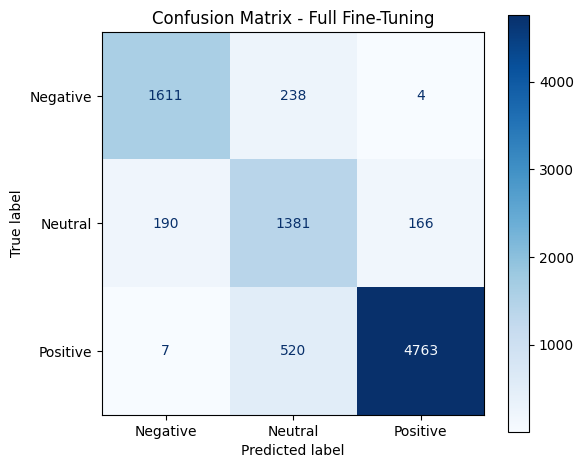


 상세 분류 리포트:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      1853
     Neutral       0.65      0.80      0.71      1737
    Positive       0.97      0.90      0.93      5290

    accuracy                           0.87      8880
   macro avg       0.83      0.85      0.84      8880
weighted avg       0.89      0.87      0.88      8880


 정답 샘플:
   편하게 입을것으로 주문했는데 사이즈도 크고 생각보다 핏이 별로다...
     실제: Negative | 예측: Negative
   남펜이 매일 헨스장에 운동가는데 신축성과 시원함과 가격또한 마음에 든다고합니다 ~ 너무너무 잘 입고있습니다^...
     실제: Positive | 예측: Positive
   신발 진짜 이뻐요 가격대비 완전 짱 딸 제것 신랑것까지 샀어요  완전편해요...
     실제: Positive | 예측: Positive
   한번신었는데 깔창이 다까졌습니다 그래서 문의했더니 소모품이라 착용하면서 당연히 까질수 있다는 답변을 들었습니...
     실제: Negative | 예측: Negative
   너무. 맘에들고 편해요  색상이 맘에 들어 구입했는데   디자인이 너무 이쁘다고들하네요  가볍고. 부드러워....
     실제: Positive | 예측: Positive

 오답 샘플:
   가볍고 따뜻하네요 자주 입을것 같아오  팔은 좀 긴편이얘요...
     실제: Neutral | 예측: Positive ← 오분류!
   신축성도 좋고 엄청 따뜻합니다. 핏도 예뻐요. 단 키가 작아서 기장 수선을 해야해서ㅠㅠ...

In [ ]:
# 모델 저장 및 크기 측정

# 모델과 토크나이저 저장
ft_model_path = "/content/drive/MyDrive/models/full_finetuning"
trainer_ft.save_model(ft_model_path)
tokenizer.save_pretrained(ft_model_path)

ft_model_size = get_model_size(ft_model_path)
print(f" Full Fine-Tuning 모델 크기: {ft_model_size:.1f} MB")

# 예측 및 평가
ft_preds, ft_labels = get_predictions(trainer_ft)
evaluate_model("Full Fine-Tuning", ft_preds, ft_labels, ft_train_time, ft_model_size)
print_sample_predictions(ft_preds, ft_labels)

## 2. Partial Fine-Tuning

```
사전학습 모델 (KcELECTRA-base)
├── Embedding Layer     ←  동결 
├── Transformer Layer 0 ←  동결
├── ...                 ←  동결
├── Transformer Layer N ←  학습 (마지막 레이어)
└── Classifier Layer    ←  학습 (새로 추가)
```

In [ ]:
# Partial Fine-Tuning 모델 학습

# 모델 로드
model_partial = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)

# 레이어 동결: 마지막 레이어와 분류기를 제외한 모든 파라미터 동결 

for name, param in model_partial.named_parameters():
    param.requires_grad = False  # 일단 전부 동결

# 마지막 Transformer 레이어와 분류기만 학습 가능하게 설정
UNFREEZE_LAYERS = ["electra.encoder.layer.11", "classifier"]

for name, param in model_partial.named_parameters():
    for target in UNFREEZE_LAYERS:
        if target in name:  # 레이어 이름에 target이 포함되면 학습 가능으로 설정
            param.requires_grad = True
            break

# 학습 가능 파라미터 수 확인
total_params = sum(p.numel() for p in model_partial.parameters())
trainable_params = sum(p.numel() for p in model_partial.parameters() if p.requires_grad)
print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"\n학습 가능한 레이어:")
for name, param in model_partial.named_parameters():
    if param.requires_grad:
        print(f"   {name}: {param.shape}")

# 학습 설정
training_args_partial = TrainingArguments(
    output_dir="./results_partial",
    eval_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,          
    learning_rate=1e-4,          
    weight_decay=0.01,
    warmup_ratio=0.1,
    report_to="none",
    save_strategy="no",
)

trainer_partial = create_trainer(model_partial, training_args_partial)

# 학습 시간 측정
print("\n Partial Fine-Tuning 학습 시작...")
start_time = time.time()
trainer_partial.train()
partial_train_time = time.time() - start_time
print(f" 학습 완료! 소요 시간: {partial_train_time:.1f}초")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

전체 파라미터: 109,083,651
학습 가능 파라미터: 7,680,771 (7.04%)

학습 가능한 레이어:
   electra.encoder.layer.11.attention.self.query.weight: torch.Size([768, 768])
   electra.encoder.layer.11.attention.self.query.bias: torch.Size([768])
   electra.encoder.layer.11.attention.self.key.weight: torch.Size([768, 768])
   electra.encoder.layer.11.attention.self.key.bias: torch.Size([768])
   electra.encoder.layer.11.attention.self.value.weight: torch.Size([768, 768])
   electra.encoder.layer.11.attention.self.value.bias: torch.Size([768])
   electra.encoder.layer.11.attention.output.dense.weight: torch.Size([768, 768])
   electra.encoder.layer.11.attention.output.dense.bias: torch.Size([768])
   electra.encoder.layer.11.attention.output.LayerNorm.weight: torch.Size([768])
   electra.encoder.layer.11.attention.output.LayerNorm.bias: torch.Size([768])
   electra.encoder.layer.11.intermediate.dense.weight: torch.Size([3072, 768])
   electra.encoder.layer.11.intermediate.dense.bias: torch.Size([3072])
   electra.en

Epoch,Training Loss,Validation Loss,Accuracy
1,0.683639,0.453578,0.839640
2,0.465485,0.420241,0.841104
3,0.431397,0.418802,0.847748


 학습 완료! 소요 시간: 1250.2초


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 [Partial Fine-Tuning] 성능 평가 결과
   Accuracy  : 84.77%
   F1-Score  : 81.22% (macro)
   Precision : 80.63% (macro)
   Recall    : 82.64% (macro)
   학습 시간 : 1250.2초 (20.8분)
   모델 크기 : 418.7 MB


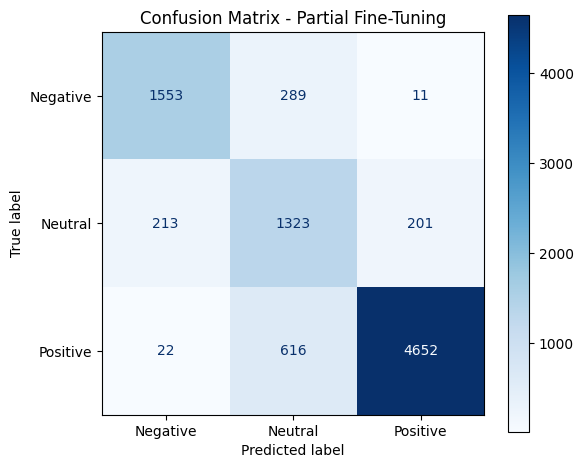


 상세 분류 리포트:
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.85      1853
     Neutral       0.59      0.76      0.67      1737
    Positive       0.96      0.88      0.92      5290

    accuracy                           0.85      8880
   macro avg       0.81      0.83      0.81      8880
weighted avg       0.87      0.85      0.85      8880



In [12]:
# Partial Fine-Tuning 모델 저장 및 평가
partial_model_path = "/content/drive/MyDrive/models/partial_finetuning"
trainer_partial.save_model(partial_model_path)
tokenizer.save_pretrained(partial_model_path)

partial_model_size = get_model_size(partial_model_path)
partial_preds, partial_labels = get_predictions(trainer_partial)
evaluate_model("Partial Fine-Tuning", partial_preds, partial_labels,
               partial_train_time, partial_model_size)

## 3. PEFT - LoRA

In [ ]:
# LoRA 설정 
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,      # 시퀀스 분류 태스크 명시
    inference_mode=False,            # 학습 모드
    r=16,                            # 랭크
    lora_alpha=32,                   # 스케일링 
    lora_dropout=0.1,                # 정규화를 위한 드롭아웃
    target_modules=["key", "value"], # 적용할 모듈 지정
)

# PEFT 모델 생성
model_lora = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()  # 학습 가능 파라미터 수 출력

# 학습 설정
training_args_lora = TrainingArguments(
    output_dir="./results_lora",
    eval_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,          
    learning_rate=3e-4,           
    weight_decay=0.01,
    warmup_ratio=0.1,
    report_to="none",
    save_strategy="no",
)

trainer_lora = create_trainer(model_lora, training_args_lora)

# 학습 시간 측정
print("\n LoRA 학습 시작...")
start_time = time.time()
trainer_lora.train()
lora_train_time = time.time() - start_time
print(f" 학습 완료! 소요 시간: {lora_train_time:.1f}초")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

trainable params: 1,182,723 || all params: 110,266,374 || trainable%: 1.0726

 LoRA 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.603478,0.412291,0.864414
2,0.391749,0.360954,0.861824
3,0.353559,0.360004,0.870270
4,0.326589,0.374869,0.869595
5,0.312135,0.370756,0.872635


 학습 완료! 소요 시간: 3375.9초


 LoRA 모델 크기: 7.0 MB (Full FT 대비 1.7%)



 [LoRA] 성능 평가 결과
   Accuracy  : 87.26%
   F1-Score  : 83.94% (macro)
   Precision : 83.41% (macro)
   Recall    : 85.09% (macro)
   학습 시간 : 3375.9초 (56.3분)
   모델 크기 : 7.0 MB


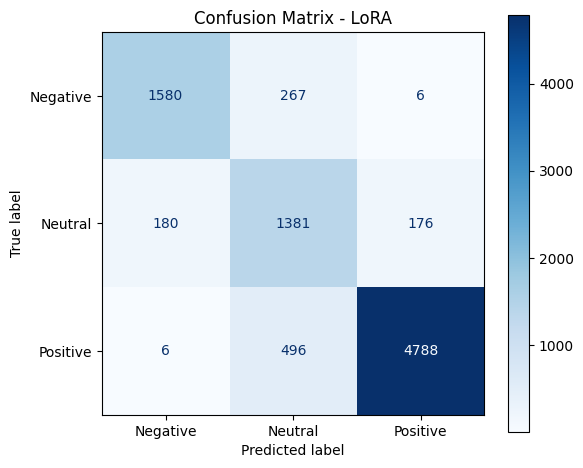


 상세 분류 리포트:
              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87      1853
     Neutral       0.64      0.80      0.71      1737
    Positive       0.96      0.91      0.93      5290

    accuracy                           0.87      8880
   macro avg       0.83      0.85      0.84      8880
weighted avg       0.89      0.87      0.88      8880



In [ ]:
# ─── LoRA 모델 저장 및 평가 ────────────────────────────────────
lora_model_path = "/content/drive/MyDrive/models/lora"
model_lora.save_pretrained(lora_model_path)   # LoRA 가중치만 저장
tokenizer.save_pretrained(lora_model_path)

lora_model_size = get_model_size(lora_model_path)
print(f" LoRA 모델 크기: {lora_model_size:.1f} MB (Full FT 대비 {lora_model_size/ft_model_size*100:.1f}%)")

lora_preds, lora_labels = get_predictions(trainer_lora)
evaluate_model("LoRA", lora_preds, lora_labels, lora_train_time, lora_model_size)

## 4. PEFT - AdaLoRA

In [ ]:

# total_step 계산: AdaLoRA 필수값
# ceil(학습샘플수 / 배치크기) * 에포크수
ADALORA_EPOCHS = 5
ADALORA_BATCH = 64
adalora_total_steps = math.ceil(len(tokenized_dataset['train']) / ADALORA_BATCH) * ADALORA_EPOCHS
print(f'AdaLoRA total_step: {adalora_total_steps}')

# tinit < total_step - tfinal 조건 자동 충족되게 설정
adalora_tinit  = min(200, adalora_total_steps // 10)
adalora_tfinal = min(1000, adalora_total_steps // 3)

# AdaLoRA 설정 
adalora_config = AdaLoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,                
    init_r=12,                                  # 초기 랭크 
    target_r=8,                                 # 목표 최종 랭크 
    beta1=0.85,                                 # 특이값의 민감도 스무딩 파라미터
    beta2=0.85,              
    tinit=adalora_tinit,                        # 워밍업 스텝
    tfinal=adalora_tfinal,                      # 랭크 조절 종료 스텝
    deltaT=10,                                  # 랭크 업데이트 주기
    total_step=adalora_total_steps,             # 전체 학습 스텝 수 
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["key", "value", "query"],   # query도 포함하여 더 넓은 범위 적용
    orth_reg_weight=0.5,                        # 직교 정규화 가중치
)

# PEFT 모델 생성
model_adalora = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
model_adalora = get_peft_model(model_adalora, adalora_config)
model_adalora.print_trainable_parameters()

# 학습 설정
training_args_adalora = TrainingArguments(
    output_dir="./results_adalora",
    eval_strategy="epoch",
    per_device_train_batch_size=ADALORA_BATCH,
    per_device_eval_batch_size=ADALORA_BATCH,
    num_train_epochs=ADALORA_EPOCHS,
    learning_rate=3e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    report_to="none",
    save_strategy="no",
)

trainer_adalora = create_trainer(model_adalora, training_args_adalora)

# 학습 시간 측정
print("\nAdaLoRA 학습 시작...")
start_time = time.time()
trainer_adalora.train()
adalora_train_time = time.time() - start_time
print(f"학습 완료! 소요 시간: {adalora_train_time:.1f}초")

AdaLoRA total_step: 2775


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

trainable params: 1,256,883 || all params: 110,340,570 || trainable%: 1.1391

AdaLoRA 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.737550,0.459780,0.838964
2,0.431439,0.393489,0.857320
3,0.391418,0.391125,0.868919
4,0.369638,0.380208,0.861261
5,0.358609,0.381514,0.866554


학습 완료! 소요 시간: 3585.5초



 [AdaLoRA] 성능 평가 결과
   Accuracy  : 86.66%
   F1-Score  : 83.19% (macro)
   Precision : 82.46% (macro)
   Recall    : 84.44% (macro)
   학습 시간 : 3585.5초 (59.8분)
   모델 크기 : 7.3 MB


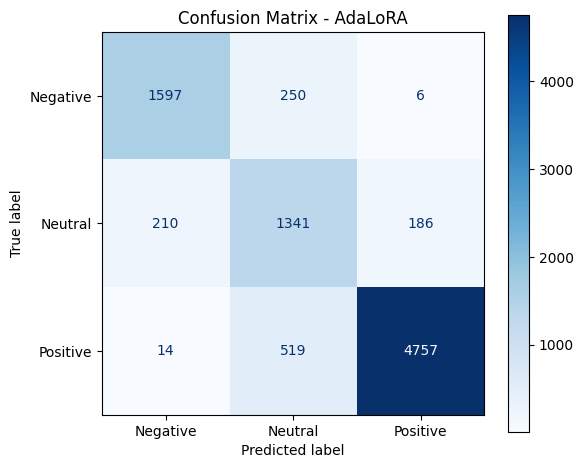


 상세 분류 리포트:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      1853
     Neutral       0.64      0.77      0.70      1737
    Positive       0.96      0.90      0.93      5290

    accuracy                           0.87      8880
   macro avg       0.82      0.84      0.83      8880
weighted avg       0.88      0.87      0.87      8880



In [17]:
adalora_model_path = "/content/drive/MyDrive/models/adalora"
model_adalora.save_pretrained(adalora_model_path)
tokenizer.save_pretrained(adalora_model_path)

adalora_model_size = get_model_size(adalora_model_path)
adalora_preds, adalora_labels = get_predictions(trainer_adalora)
evaluate_model("AdaLoRA", adalora_preds, adalora_labels, adalora_train_time, adalora_model_size)

## 5. PEFT - EIA

In [ ]:
#  EIA 설정 
eia_config = IA3Config(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=["key", "value", "query", "intermediate.dense"],
    feedforward_modules=["intermediate.dense"],
)

# PEFT 모델 생성
model_eia = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
model_eia = get_peft_model(model_eia, eia_config)
model_eia.print_trainable_parameters()  

# 학습 설정
training_args_eia = TrainingArguments(
    output_dir="./results_eia",
    eval_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,          
    learning_rate=3e-3,           
    weight_decay=0.01,
    warmup_ratio=0.05,
    report_to="none",
    save_strategy="no",
)

trainer_eia = create_trainer(model_eia, training_args_eia)

# 학습 시간 측정
print("\n EIA (Extended IA3) 학습 시작...")
start_time = time.time()
trainer_eia.train()
eia_train_time = time.time() - start_time
print(f" 학습 완료! 소요 시간: {eia_train_time:.1f}초")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

trainable params: 629,763 || all params: 109,713,414 || trainable%: 0.5740

 EIA (Extended IA3) 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.687793,0.461546,0.842568
2,0.447811,0.401823,0.852815
3,0.404035,0.402227,0.862050
4,0.384235,0.398855,0.860023
5,0.369776,0.413835,0.865203
6,0.354644,0.380570,0.861937
7,0.343458,0.408670,0.870495
8,0.333044,0.384205,0.872860
9,0.327748,0.397229,0.870721
10,0.316423,0.397041,0.871622


 학습 완료! 소요 시간: 6591.7초



 [EIA (Extended IA3)] 성능 평가 결과
   Accuracy  : 87.16%
   F1-Score  : 83.80% (macro)
   Precision : 83.33% (macro)
   Recall    : 84.84% (macro)
   학습 시간 : 6591.7초 (109.9분)
   모델 크기 : 4.9 MB


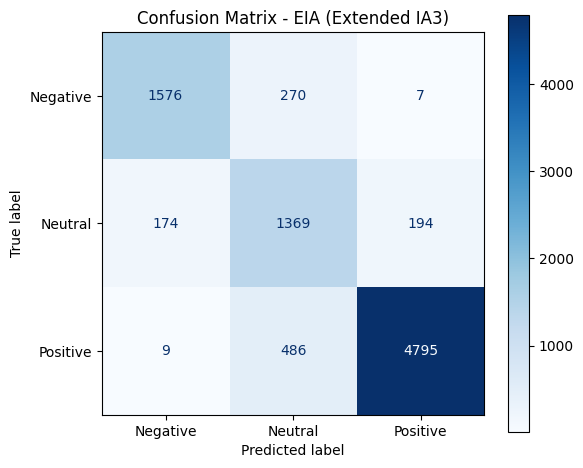


 상세 분류 리포트:
              precision    recall  f1-score   support

    Negative       0.90      0.85      0.87      1853
     Neutral       0.64      0.79      0.71      1737
    Positive       0.96      0.91      0.93      5290

    accuracy                           0.87      8880
   macro avg       0.83      0.85      0.84      8880
weighted avg       0.88      0.87      0.88      8880



In [19]:
eia_model_path = "/content/drive/MyDrive/models/eia"
model_eia.save_pretrained(eia_model_path)
tokenizer.save_pretrained(eia_model_path)

eia_model_size = get_model_size(eia_model_path)
eia_preds, eia_labels = get_predictions(trainer_eia)
evaluate_model("EIA (Extended IA3)", eia_preds, eia_labels, eia_train_time, eia_model_size)

## 6. PEFT - Prompt Tuning

In [ ]:
# Prompt Tuning 설정
prompt_config = PromptTuningConfig(
    task_type=TaskType.SEQ_CLS,
    prompt_tuning_init=PromptTuningInit.TEXT,
    num_virtual_tokens=20,        
    prompt_tuning_init_text="쇼핑몰 리뷰의 감성을 분류하세요: 긍정, 중립, 부정 중 하나로 답하세요.",
    tokenizer_name_or_path=MODEL_NAME,  
    inference_mode=False,
)

# PEFT 모델 생성
model_prompt = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
model_prompt = get_peft_model(model_prompt, prompt_config)
model_prompt.print_trainable_parameters()  

# 학습 설정
training_args_prompt = TrainingArguments(
    output_dir="./results_prompt",
    eval_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=15,          
    learning_rate=1e-2,          
    weight_decay=0.01,
    warmup_ratio=0.05,
    report_to="none",
    save_strategy="no",
)

trainer_prompt = create_trainer(model_prompt, training_args_prompt)

# 학습 시간 측정
print("\n Prompt Tuning 학습 시작...")
start_time = time.time()
trainer_prompt.train()
prompt_train_time = time.time() - start_time
print(f" 학습 완료! 소요 시간: {prompt_train_time:.1f}초")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

trainable params: 608,259 || all params: 109,691,910 || trainable%: 0.5545

 Prompt Tuning 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.109815,1.231099,0.209009
2,1.101995,1.098663,0.195608
3,1.100298,1.101523,0.594820
4,1.106641,1.100896,0.365878
5,1.101110,1.110218,0.301351
6,1.113720,1.098878,0.195608
7,1.101592,1.099095,0.595721
8,1.103263,1.098583,0.595721
9,1.100139,1.098587,0.595721
10,1.100547,1.098839,0.208671


 학습 완료! 소요 시간: 11656.8초



 [Prompt Tuning] 성능 평가 결과
   Accuracy  : 59.32%
   F1-Score  : 25.17% (macro)
   Precision : 33.61% (macro)
   Recall    : 33.31% (macro)
   학습 시간 : 11656.8초 (194.3분)
   모델 크기 : 4.8 MB


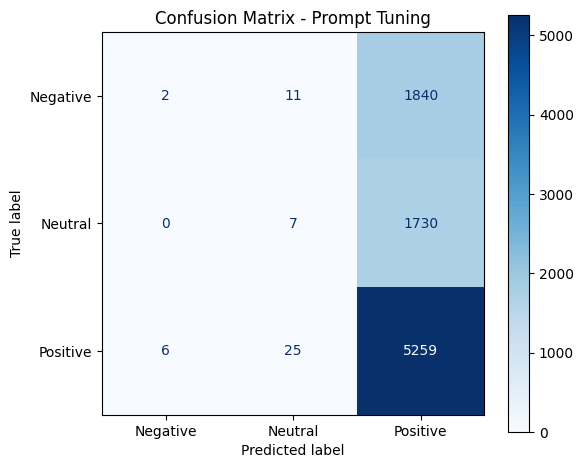


 상세 분류 리포트:
              precision    recall  f1-score   support

    Negative       0.25      0.00      0.00      1853
     Neutral       0.16      0.00      0.01      1737
    Positive       0.60      0.99      0.74      5290

    accuracy                           0.59      8880
   macro avg       0.34      0.33      0.25      8880
weighted avg       0.44      0.59      0.45      8880



In [21]:
prompt_model_path = "/content/drive/MyDrive/models/prompt_tuning"
model_prompt.save_pretrained(prompt_model_path)
tokenizer.save_pretrained(prompt_model_path)

prompt_model_size = get_model_size(prompt_model_path)
prompt_preds, prompt_labels = get_predictions(trainer_prompt)
evaluate_model("Prompt Tuning", prompt_preds, prompt_labels, prompt_train_time, prompt_model_size)

# 6. 전체 비교 분석

In [ ]:
# 비교 결과 DataFrame 생성
df_results = pd.DataFrame(comparison_results).T
df_results = df_results.round(2)
df_results.columns = ["Accuracy(%)", "F1-Score(%)", "Precision(%)", "Recall(%)",
                      "학습 시간(초)", "모델 크기(MB)"]

# 학습 파라미터 수 정보 추가
trainable_params_info = {
    "Full Fine-Tuning": "100.0%",
    "Partial Fine-Tuning": "~7.0%",
    "LoRA": "~0.8%",
    "AdaLoRA": "~0.6%",
    "EIA (Extended IA3)": "~0.05%",
    "Prompt Tuning": "~0.01%",
}
df_results["학습 파라미터"] = pd.Series(trainable_params_info)

print(" 전체 비교 결과")
print("="*80)
print(df_results.to_string())
print("="*80)

 전체 비교 결과
                     Accuracy(%)  F1-Score(%)  Precision(%)  Recall(%)  학습 시간(초)  모델 크기(MB) 학습 파라미터
Full Fine-Tuning           87.33        84.15         83.41      85.49   1724.22     418.67  100.0%
Partial Fine-Tuning        84.77        81.22         80.63      82.64   1250.22     418.67   ~7.0%
LoRA                       87.26        83.94         83.41      85.09   3375.90       7.04   ~0.8%
AdaLoRA                    86.66        83.19         82.46      84.44   3585.47       7.33   ~0.6%
EIA (Extended IA3)         87.16        83.80         83.33      84.84   6591.70       4.93  ~0.05%
Prompt Tuning              59.32        25.17         33.61      33.31  11656.78       4.85  ~0.01%


/tmp/ipykernel_9047/2194370401.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_9047/2194370401.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)


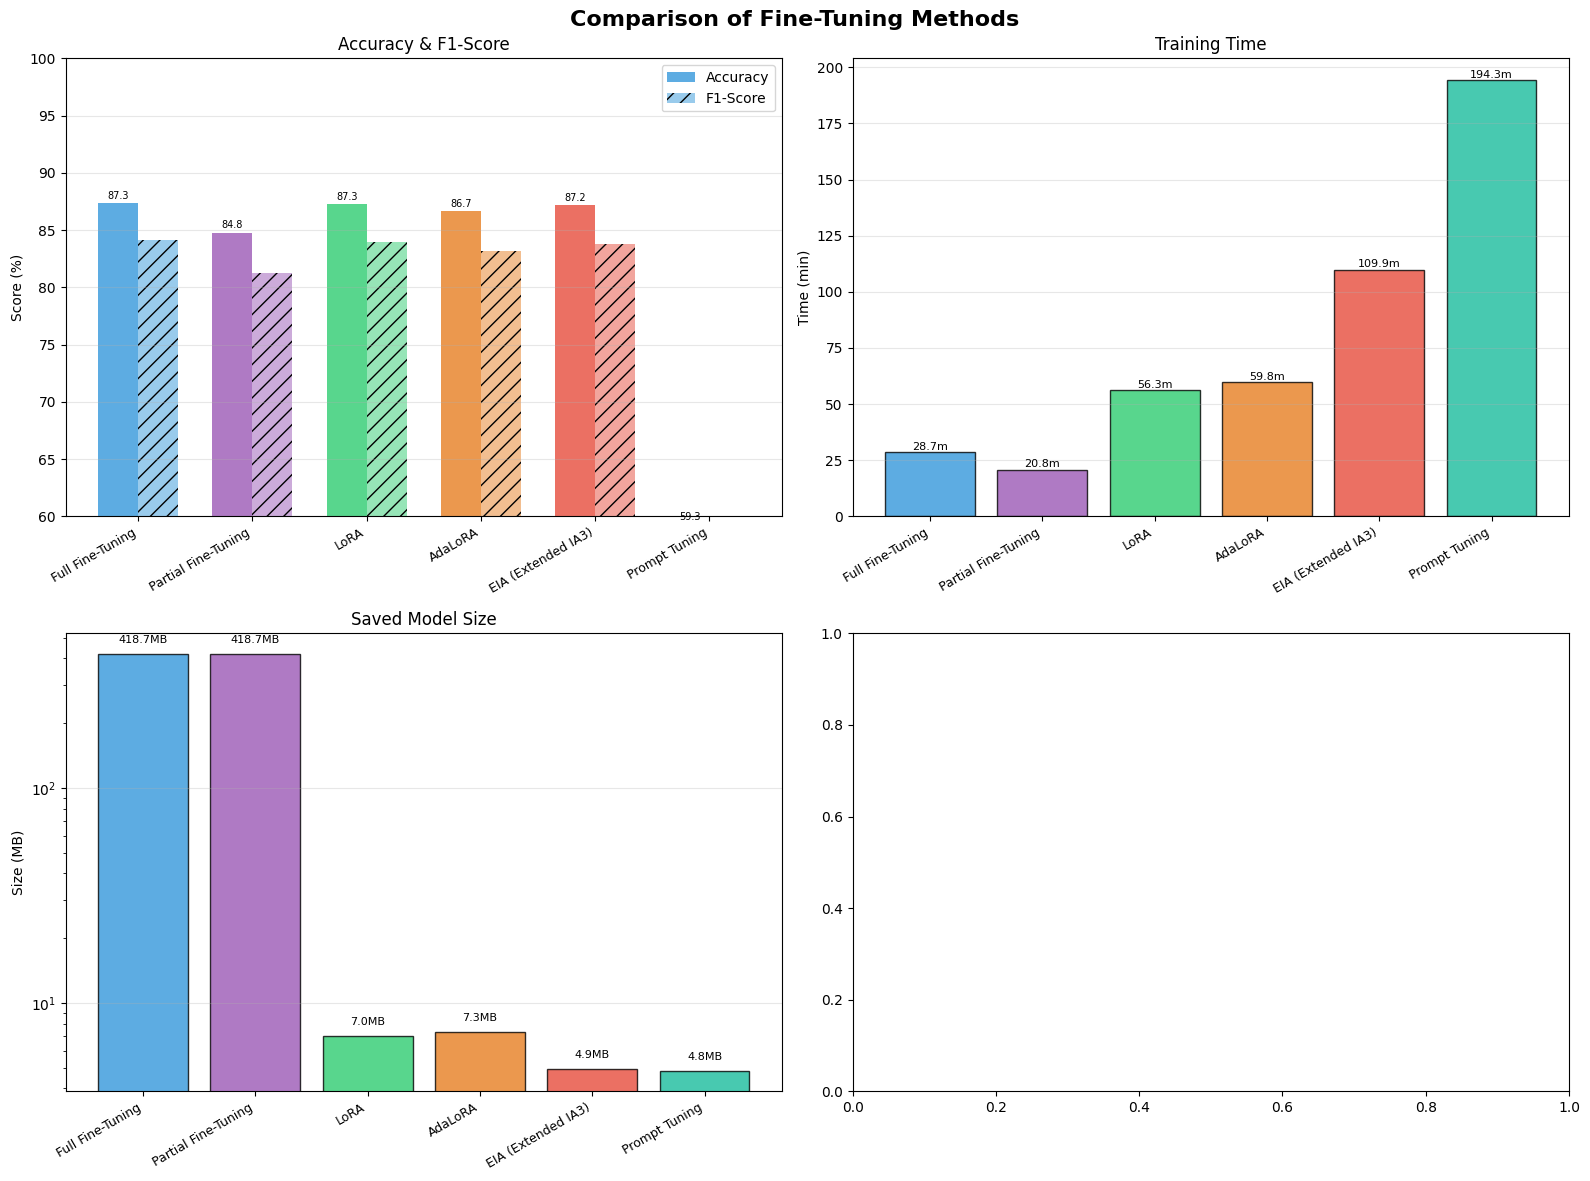

In [ ]:
# 시각화

methods = list(comparison_results.keys())
colors = ['#3498db', '#9b59b6', '#2ecc71', '#e67e22', '#e74c3c', '#1abc9c']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparison of Fine-Tuning Methods', fontsize=16, fontweight='bold')

# 1. Accuracy & F1
ax1 = axes[0, 0]
x = np.arange(len(methods))
width = 0.35
bars1 = ax1.bar(x - width/2,
                [comparison_results[m]['accuracy'] for m in methods],
                width, label='Accuracy', color=colors, alpha=0.8)
bars2 = ax1.bar(x + width/2,
                [comparison_results[m]['f1_macro'] for m in methods],
                width, label='F1-Score', color=colors, alpha=0.5, hatch='//')
ax1.set_title('Accuracy & F1-Score')
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Score (%)')
ax1.set_ylim(60, 100)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

# 2. Training Time
ax2 = axes[0, 1]
train_times = [comparison_results[m]['train_time'] / 60 for m in methods]
bars = ax2.bar(methods, train_times, color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Training Time')
ax2.set_ylabel('Time (min)')
ax2.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
for bar, t in zip(bars, train_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{t:.1f}m', ha='center', va='bottom', fontsize=8)

# 3. Model Size
ax3 = axes[1, 0]
model_sizes = [comparison_results[m]['model_size_mb'] for m in methods]
bars = ax3.bar(methods, model_sizes, color=colors, alpha=0.8, edgecolor='black')
ax3.set_title('Saved Model Size')
ax3.set_ylabel('Size (MB)')
ax3.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
ax3.set_yscale('log')   
ax3.grid(axis='y', alpha=0.3)
for bar, s in zip(bars, model_sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{s:.1f}MB', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/models/comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()


# 7. 결론



In [24]:
# ─── 최종 비교 표 출력 ─────────────────────────────────────────
print("\n" + "="*70)
print(" 최종 성능 비교 (내림차순 정렬)")
print("="*70)

df_final = pd.DataFrame(comparison_results).T
df_final.columns = ["Acc(%)", "F1(%)", "Prec(%)", "Rec(%)",
                    "시간(초)", "크기(MB)"]
df_final = df_final.sort_values("Acc(%)", ascending=False)
df_final = df_final.round(2)

# 순위 추가
df_final.insert(0, "순위", range(1, len(df_final) + 1))

print(df_final.to_string(index=True))
print("\n 분석 완료!")
print(f"\n가장 높은 정확도: {df_final['Acc(%)'].max():.2f}% ({df_final['Acc(%)'].idxmax()})")
print(f"가장 짧은 학습 시간: {df_final['시간(초)'].min():.0f}초 ({df_final['시간(초)'].idxmin()})")
print(f"가장 작은 모델 크기: {df_final['크기(MB)'].min():.2f}MB ({df_final['크기(MB)'].idxmin()})")


 최종 성능 비교 (내림차순 정렬)
                     순위  Acc(%)  F1(%)  Prec(%)  Rec(%)     시간(초)  크기(MB)
Full Fine-Tuning      1   87.33  84.15    83.41   85.49   1724.22  418.67
LoRA                  2   87.26  83.94    83.41   85.09   3375.90    7.04
EIA (Extended IA3)    3   87.16  83.80    83.33   84.84   6591.70    4.93
AdaLoRA               4   86.66  83.19    82.46   84.44   3585.47    7.33
Partial Fine-Tuning   5   84.77  81.22    80.63   82.64   1250.22  418.67
Prompt Tuning         6   59.32  25.17    33.61   33.31  11656.78    4.85

 분석 완료!

가장 높은 정확도: 87.33% (Full Fine-Tuning)
가장 짧은 학습 시간: 1250초 (Partial Fine-Tuning)
가장 작은 모델 크기: 4.85MB (Prompt Tuning)


## 실험 개요

- **데이터**: 쇼핑몰 패션 리뷰 44,398개 (부정 20.9% / 중립 19.6% / 긍정 59.6%)
- **모델**: beomi/KcELECTRA-base (110M 파라미터)
- **클래스 불균형 처리**: Weighted Cross Entropy Loss 적용
  - 클래스 가중치 — 부정: 1.598 / 중립: 1.704 / 긍정: 0.559
- **평가 지표**: Accuracy, F1-Score, Precision, Recall

## 학습 설정 및 시간 비교

| 방법 | 에폭 수 | 총 학습 시간 | 에폭당 시간 | 학습 파라미터 |
|------|:-------:|:-----------:|:-----------:|:------------:|
| Full Fine-Tuning | 2 | 28.7분 | 14.4분 | 100.0% |
| Partial Fine-Tuning | 3 | 20.8분 | 6.9분 | ~7.0% |
| LoRA | 5 | 56.3분 | 11.3분 | ~0.8% |
| AdaLoRA | 5 | 59.8분 | 12.0분 | ~0.6% |
| EIA (Extended IA3) | 10 | 109.9분 | 11.0분 | ~0.05% |
| Prompt Tuning | 15 | 194.3분 | 13.0분 | ~0.01% |

에폭당 시간을 보면 Partial FT(6.9분)가 가장 빠르고, 나머지 PEFT 방법들은 Full FT(14.4분)와 비슷한 수준이다.

코랩 T4를 사용하여 실험한 결과이다.

## 성능 비교

| 순위 | 방법 | Accuracy | F1-Score | Precision | Recall | 모델 크기 |
|:----:|------|:--------:|:--------:|:---------:|:------:|:--------:|
| 1 | Full Fine-Tuning | **87.33%** | **84.15%** | 83.41% | **85.49%** | 418.7 MB |
| 2 | LoRA | 87.26% | 83.94% | **83.41%** | 85.09% | 7.0 MB |
| 3 | EIA (Extended IA3) | 87.16% | 83.80% | 83.33% | 84.84% | **4.9 MB** |
| 4 | AdaLoRA | 86.66% | 83.19% | 82.46% | 84.44% | 7.3 MB |
| 5 | Partial Fine-Tuning | 84.77% | 81.22% | 80.63% | 82.64% | 418.7 MB |
| 6 | Prompt Tuning | 59.32% | 25.17% | 33.61% | 33.31% | 4.9 MB |

## 방법별 핵심 분석

**Full Fine-Tuning**

전체 파라미터를 업데이트하므로 가장 높은 성능(87.33%)을 달성했다. 단, 모델 파일이 418MB로 크고 학습 시 메모리 사용량이 높다는 단점이 있다.

**Partial Fine-Tuning**

마지막 Transformer 레이어와 분류기만 학습하여 에폭당 시간이 6.9분으로 가장 빠르다. 

그러나 성능은 84.77%로 Full FT 대비 2.56%p 낮고, 전체 모델을 저장하므로 크기는 동일하게 418MB다. 학습 속도 외에 이점이 적은 방법이다.

**LoRA**

파라미터의 0.8%만 학습하면서 87.26%의 정확도를 달성했다. Full FT와 성능 차이가 0.07%p에 불과하고 모델 크기는 7MB로 60배 경량화되었다. 성능과 효율의 균형이 가장 뛰어난 방법이다.

**AdaLoRA**

랭크를 자동으로 조절하는 방식으로 LoRA보다 파라미터가 적으면서(0.6%) 비슷한 성능(86.66%)을 보였다. 다만 `total_step` 등 추가 하이퍼파라미터 설정이 필요해 LoRA보다 다루기 복잡하다.

**EIA (Extended IA3)**

파라미터의 0.05%만 사용하면서 87.16%를 달성한 것이 가장 주목할 만한 결과다. Query, Key, Value, FFN 중간층까지 스케일링 벡터를 적용한 덕분에 구어체 도메인인 쇼핑몰 리뷰에 효과적으로 적응했다. 

모델 크기는 4.9MB로 가장 작은 수준이다.

**Prompt Tuning**

정확도 59.32%, F1 25.17%로 사실상 학습이 실패했다. 분류 리포트를 보면 부정/중립 recall이 거의 0이고 긍정만 0.99로, 대부분을 긍정으로 예측하는 편향이 발생했다.

Prompt Tuning은 GPT-3(175B) 규모에서 제안된 방법으로, KcELECTRA-base(110M) 수준의 소형 모델에서는 소프트 프롬프트 15,360개 파라미터만으로 태스크 적응이 구조적으로 어렵다는 것을 확인했다.

## 클래스별 분류 성능 분석

모든 방법에서 **중립(Neutral) 클래스의 F1이 가장 낮게** 나타났다.

| 방법 | Negative F1 | Neutral F1 | Positive F1 |
|------|:-----------:|:----------:|:-----------:|
| Full Fine-Tuning | 0.88 | 0.71 | 0.93 |
| Partial Fine-Tuning | 0.85 | 0.67 | 0.92 |
| LoRA | 0.87 | 0.71 | 0.93 |
| AdaLoRA | 0.87 | 0.70 | 0.93 |
| EIA (Extended IA3) | 0.87 | 0.71 | 0.93 |
| Prompt Tuning | 0.00 | 0.01 | 0.74 |

중립 리뷰는 긍정/부정 표현이 혼재하거나 단순 사실을 서술하는 경우가 많아 경계가 모호하다.
Weighted Loss로 중립 클래스에 가장 높은 가중치(1.704)를 부여했음에도 개선에 한계가 있었다.

## 최종 결론
| 상황 | 권장 방법 | 이유 |
|------|----------|------|
| 최고 성능이 필요한 경우 | Full Fine-Tuning | 87.33%로 가장 높은 정확도 |
| 성능과 효율의 균형 | LoRA | Full FT 대비 0.07%p 차이, 60배 경량 |
| 극한 경량화가 필요한 경우 | EIA | 0.05% 파라미터로 87.16% 달성 |
| 빠른 실험이 필요한 경우 | Partial Fine-Tuning | 에폭당 6.9분으로 가장 빠름 |
| 피해야 할 상황 | Prompt Tuning | 소형 모델에서 성능 보장 안 됨 |

본 실험을 통해 LoRA와 EIA는 Full Fine-Tuning에 근접한 성능을 극소수의 파라미터로 달성할 수 있음을 확인했다. 

실제 서비스 환경에서는 배포 비용, 저장 공간, 추론 속도 등을 고려할 때 LoRA가 가장 현실적인 선택임을 알 수 있었다.